In [22]:
#libraries
from pathlib import Path
import zipfile

import geopandas as gpd
import fiona
import matplotlib as plt
import matplotlib.pyplot as plt

import geojson
import json
import requests

import rasterio as rio
from rasterio.mask import mask
from rasterio.plot import show_hist
from rasterio.plot import show
from rasterio.merge import merge
import numpy as np
from rasterio.windows import Window

import seaborn as sns
import pandas as pd

In [23]:
#directories
home_dir= Path(r"C:\Users\twand\Documents\Python\natural_capital")
raw_data_dir = home_dir / "data" / "raw"
proces_data_dir = home_dir / "data" / "processed"
external_data_dir = home_dir / "data" / "external"

### Functies

In [24]:
def gemeente_of_interest_geodf(gpkg_path: Path, layer_name: str | None, gemeente: str, output_path: Path) -> gpd.GeoDataFrame:
    """
    choose path, layername ('gemeenten', 'provincies', 'landsgrens') and gemeente to make a new geopandas dataframe
    """
    layers = fiona.listlayers(gpkg_path)

    if layer_name is None:
        print(f'no layer specified. Available layers: {layers}')
        layer_name = layers[0] #automatisch 'gemeente' layer
        print(f'setting default layer: {layer_name}')
    
    if layer_name not in layers:
        raise ValueError(f"Layer '{layer_name}' not found. Available layers: {layers}")
    
    gdf_layer = gpd.read_file(gpkg_path, layer=layer_name)
    chosen_gemeente = gdf_layer[gdf_layer['gemeentenaam'] == gemeente].copy()
    chosen_gemeente = chosen_gemeente.to_crs('EPSG:28992') #to Amersfoort coordinate system

    print(chosen_gemeente.crs)
    print(chosen_gemeente.describe)

    return chosen_gemeente.to_file(output_path)

In [25]:
def merge_raster_to_mosaic(input_folder, output_file, **kwargs):
    """
    Merges adjacent rasters to a big raster (mosaic)
    Accepts **kwargs for rasterio.merge (e.g., nodata=-9999)
    """
    
    src_files_to_mosaic = []

    search_path = input_folder.glob("*.tif")

    for fp in search_path:
        src = rio.open(fp)
        src_files_to_mosaic.append(src)

    if not src_files_to_mosaic:
        print("Geen .tif bestanden gevonden in map!")
        return
    
    mosaic, out_trans = merge(src_files_to_mosaic, **kwargs) #RETRIEVE combined PIXEL_ARRAY and new GEOGRAPHIC_TRANSFORM
    
    show(mosaic, cmap='terrain')

    #kopieert en update metadata van de gemergde rasters
    out_meta = src.meta.copy()

    out_meta.update({"driver": "GTiff",
                    "height": mosaic.shape[1],
                    "width": mosaic.shape[2],
                    "transform": out_trans,
    })

    if 'nodata' in kwargs:
        out_meta.update({"nodata": kwargs['nodata']})

    #write merged rasters with new meta-data to "tif_out_mosaic"
    with rio.open(output_file, "w", **out_meta) as dst:
        dst.write(mosaic)
    
    print(f'mosaic sucessfully created.\nSaved at location: {output_file}')

In [26]:
#Upscalen of downscalen

from rasterio.enums import Resampling

def resample_raster(input_path, output_path, target_res=0.5):
    """
    Past de resolutie van een raster aan naar een gewenste pixelgrootte (target_res).
    """

    with rio.open(input_path) as src:
        scale_factor = src.res[0] / target_res

        #Bereken de nieuwe dimensies
        new_height = int(src.height * scale_factor)
        new_width = int(src.width * scale_factor)

        #De data inlezen en herschalen
        data = src.read(
            out_shape=(src.count, new_height, new_width),
            resampling = Resampling.average
        )

        #georeferentie bijwerken. Stapgrootte bijwerken, anders verschuift kaart
        new_transform = src.transform * src.transform.scale(
            src.width / data.shape[-1],
            src.height / data.shape[-2]
        )

        #Metadata voorbereiden voor het nieuwe bestand.
        out_meta = src.meta.copy()
        out_meta.update({
                    "driver": "GTiff",
                    "height": new_height,
                    "width": new_width,
                    "transform": new_transform,
                    "compress": "lzw" # LZW compressie houdt je bestanden klein zonder kwaliteitsverlies
                })
        
        #  nieuwe bestand opslaan.
        with rio.open(output_path, "w", **out_meta) as dst:
            dst.write(data)
    
    print(f"Gereed: {output_path.name} is nu {target_res}m resolutie.")

In [27]:
import matplotlib.pyplot as plt
from rasterio.windows import Window
from rasterio.plot import show

def check_resampling(original_path, resampled_path, window_off=(6000, 3000), size_m=10):
    """
    VISUELE VALIDATIE VAN RESAMPLING:\n 
    Vergelijkt een specifiek gebied tussen het origineel en de resampled versie.
    size_m: grootte van de subset in meters.
    """
    with rio.open(original_path) as src_high, rio.open(resampled_path) as src_low:
        
        # 1. Bereken venster voor hoge resolutie (bijv. 8cm of 25cm)
        # We pakken een gebied van 'size_m' meter
        win_high = Window(window_off[0], window_off[1], 
                          int(size_m / src_high.res[0]), 
                          int(size_m / src_high.res[1]))
        
        # 2. Bereken venster voor lage resolutie (0.5m)
        # We moeten de offset schalen omdat er minder pixels zijn!
        scale = src_low.res[0] / src_high.res[0]
        win_low = Window(int(window_off[0] / scale), 
                         int(window_off[1] / scale), 
                         int(size_m / src_low.res[0]), 
                         int(size_m / src_low.res[1]))

        # Data inlezen
        data_high = src_high.read(1, window=win_high)
        data_low = src_low.read(1, window=win_low)

        # Plotten
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
        
        show(data_high, ax=ax1, cmap='RdYlGn', title=f'Origineel ({src_high.res[0]}m)')
        show(data_low, ax=ax2, cmap='RdYlGn', title=f'Resampled ({src_low.res[0]}m)')

        plt.show()

        # Statistiek check
        print(f"--- Statistiek Vergelijking (Subset) ---")
        print(f"Origineel - Min: {data_high.min():.2f}, Max: {data_high.max():.2f}, Mean: {data_high.mean():.2f}")
        print(f"Resampled - Min: {data_low.min():.2f}, Max: {data_low.max():.2f}, Mean: {data_low.mean():.2f}")

In [28]:
def clip_raster_to_shape(input_raster_folder, gemeente_geometry, output_name):
    """"
    clips raster to a chosen shapefile or vector. 
    For example, aerial photo (RGB) clipped to municipality borders (vector/shapefile)
    """

    with rio.open(input_raster_folder) as src:

        original_names = src.descriptions
        print(f'band names:{original_names}')
        geometry_clip = [json.loads(gemeente_geometry.to_json())["features"][0]["geometry"]]
        out_image, out_transform = mask(src, shapes=geometry_clip, crop=True)

        #Omdat de mask functie het beeld bijsnijdt (crop=True), 
        # verschuift de linkerbovenhoek naar de rand van de geometrie (geom_alblas). 
        # De out_transform registreert deze nieuwe, verschoven positie.

        out_meta = src.meta.copy()
        out_meta.update({
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })

        #write clipped raster
        with rio.open(output_name, "w", **out_meta) as dst:
            dst.write(out_image)
            dst.descriptions = original_names
        
    print(f'input raster is clipped by {gemeente_geometry}.\nSaved as: {output_name}')
    print(f'preview:')

    #PREVIEW LOGICA
    print(f"Preview van Band 1 (van de {src.count} bands):")
    show(out_image[0], cmap='terrain')


In [40]:
def create_feature_stack(output_path, ndsm_path, ndsm_path_gaus, ndvi_path, rgb_path, infra_path, entropy_path, texture_path):
    # We openen de NDVI als 'Master' om de maten en coördinaten te bepalen
    with rio.open(ndvi_path) as src_master:
        master_meta = src_master.meta.copy()
        master_bounds = src_master.bounds # De geografische grenzen van de 16k x 16k kaart
        h, w = src_master.height, src_master.width
        
        # Stap 1: Lees de lagen die al 16k x 16k zijn
        print("Lagen inlezen (16k x 16k)...")
        band_ndvi = src_master.read(1)
        
        with rio.open(rgb_path) as src_rgb:
            bands_rgb = src_rgb.read()
            
        with rio.open(infra_path) as src_infra:
            band_nir = src_infra.read(1) # We pakken alleen Band 1 (NIR)

        with rio.open(entropy_path) as src_entropy:
            band_entropy = src_entropy.read(1)

        with rio.open(texture_path) as src_texture:
            band_texture = src_texture.read(1)

        # Stap 2: De nDSM 'clippen' op het gebied van de master

        print("nDSM uitlijnen op de rest...")
        with rio.open(ndsm_path) as src_ndsm:
            # Bepaal welk venster (window) van de grote nDSM overeenkomt met de master_bounds
            window = src_ndsm.window(*master_bounds)
            # Lees de nDSM in dat venster, forceer de maat naar exact h, w
            band_ndsm = src_ndsm.read(1, window=window, out_shape=(h, w))

        with rio.open(ndsm_path_gaus) as src_ndsm_gaus:
            # Bepaal welk venster (window) van de grote gaus overeenkomt met de master_bounds
            window = src_ndsm_gaus.window(*master_bounds)
            # Lees de nDSM in dat venster, forceer de maat naar exact h, w
            band_gaus = src_ndsm_gaus.read(1, window=window, out_shape=(h, w))

        # Stap 3: Stack maken (9 bands)
        layers = [
            np.expand_dims(band_ndsm, axis=0),      # 1: Hoogte - Wordt (1, H, W)
            np.expand_dims(band_gaus, axis=0),      # 2  Hoogte smoothed
            np.expand_dims(band_ndvi, axis=0),      # 3: NDVI
            bands_rgb,                              # 4, 5, 6: R, G, B
            np.expand_dims(band_nir, axis=0),       # 7: NIR
            np.expand_dims(band_entropy, axis=0),   #8 Entropy
            np.expand_dims(band_texture, axis=0)    #9 Texture
        ]
        
        full_stack = np.concatenate(layers, axis=0).astype('float32')

        # Stap 4: Opslaan
        master_meta.update({
            "count": 9,
            "dtype": 'float32',
            "compress": 'lzw',
            "BIGTIFF": "YES"
        })

        with rio.open(output_path, "w", **master_meta) as dst:
            dst.write(full_stack)
            dst.descriptions = ['nDSM', 'nDSM_Gaussian', 'NDVI', 'Red', 'Green', 'Blue', 'NIR', 'entropy', 'texture']
            
    print(f"Gelukt. Stack opgeslagen: {output_path.name}")
    print(f"Vorm van de stack: {full_stack.shape}")

In [36]:
import numpy as np
import rasterio
from skimage.color import rgb2gray
from skimage.filters.rank import entropy
from skimage.morphology import disk
from scipy.ndimage import generic_filter, uniform_filter

def create_fast_texture_layers(rgb_path, output_dir, window_radius=3):
    # window_radius 3 = diameter ~7 pixels (dus vergelijkbaar met window_size=7)
    
    print("Bezig met inlezen...")
    with rasterio.open(rgb_path) as src:
        # Lees data en zet om naar Grayscale (0-255 uint8 is nodig voor rank filters)
        rgb_data = src.read([1, 2, 3])
        profile = src.profile #bv. projectie RD New, pixels zijn 0.5m groot, ik heb X rijen en Y kolommen
        
        # Transpose en grayscale
        rgb_reshaped = np.transpose(rgb_data, (1, 2, 0))
        gray_img = (rgb2gray(rgb_reshaped) * 255).astype(np.uint8)

    print("Berekenen Entropy (geoptimaliseerd)...")
    # Dit is C-code onder water. Veel sneller.
    # disk(3) maakt een cirkelvormig venster met radius 3
    entropy_map = entropy(gray_img, disk(window_radius))

    print("Berekenen 'Contrast' (via Standaard Deviatie)...")
    # TRUC: Standaard Deviatie is een super snelle benadering voor Contrast/Textuur
    # Formule: std = sqrt( E[x^2] - (E[x])^2 )
    
    img_float = gray_img.astype(float)
    c1 = uniform_filter(img_float, size=window_radius*2, mode='reflect')
    c2 = uniform_filter(img_float*img_float, size=window_radius*2, mode='reflect')
    std_map = np.sqrt(c2 - c1*c1)

    # Opslaan
    print("Opslaan...")
    profile.update(dtype=rasterio.float32, count=1)
    
    entropy_path = output_dir / "RGB_texture_entropy_fast.tif"
    contrast_path = output_dir / "RGB_texture_std_fast.tif" # Std = Contrast proxy
    
    with rasterio.open(entropy_path, 'w', **profile) as dst:
        dst.write(entropy_map.astype(rasterio.float32), 1)
        
    with rasterio.open(contrast_path, 'w', **profile) as dst:
        dst.write(std_map.astype(rasterio.float32), 1)
        
    print("Klaar!")
    return contrast_path, entropy_path

# Uitvoeren
create_fast_texture_layers(
    proces_data_dir / "RGB_05m.tif", 
    proces_data_dir
)

Bezig met inlezen...
Berekenen Entropy (geoptimaliseerd)...
Berekenen 'Contrast' (via Standaard Deviatie)...


C:\Users\twand\AppData\Local\Temp\ipykernel_4320\3292105140.py:33: RuntimeWarning: invalid value encountered in sqrt
  std_map = np.sqrt(c2 - c1*c1)


Opslaan...
Klaar!


(WindowsPath('C:/Users/twand/Documents/Python/natural_capital/data/processed/RGB_texture_std_fast.tif'),
 WindowsPath('C:/Users/twand/Documents/Python/natural_capital/data/processed/RGB_texture_entropy_fast.tif'))

In [30]:
import rasterio as rio
from rasterio import features, windows
import geopandas as gpd
import pandas as pd
import numpy as np
import os

def maak_training_dataset_tiled(raster_path, vector_path, output_csv_path):
    """
    Zet een satellietbeeld en een vectorbestand om naar een CSV voor Machine Learning.
    Verwerkt de data in kleine blokjes (tiles) om geheugenproblemen te voorkomen.
    """
    # 1: Voorbereiding bestanden
    if os.path.exists(output_csv_path):
        os.remove(output_csv_path)
        print(f"Oud bestand verwijderd: {output_csv_path}")

    vector_data = gpd.read_file(vector_path) #de gelabelde polygonen

    # 2: Labels van polygonen omzetten naar getallen
    kolom_namen = ['boom', 'gras', 'gebouw', 'water_weg']
    name_to_num = {naam: i+1 for i, naam in enumerate(kolom_namen)}
    num_to_name = {v: k for k, v in name_to_num.items()}
    
    vector_data['label_naam'] = vector_data[kolom_namen].astype(float).idxmax(axis=1) #pakt de naam van de kolom die de hoogste waarde heef
    vector_data['label_nummer'] = vector_data['label_naam'].map(name_to_num) #converts text to the ID (name_to_num)
    
    print("Start met het verwerken van tegels (tiles)...")

    # 3: Satellietbeeld openen en verwerken
    with rio.open(raster_path) as satelliet_beeld:
        
        if vector_data.crs != satelliet_beeld.crs:
            print(f"Projecties verschillen. Vector wordt omgezet naar {satelliet_beeld.crs}")
            vector_data = vector_data.to_crs(satelliet_beeld.crs)
            
        band_namen = [satelliet_beeld.descriptions[i] or f"band_{i+1}" for i in range(satelliet_beeld.count)]
        
        is_eerste_blokje = True 

        # LOOP 
        for blok_index, venster in satelliet_beeld.block_windows(1):

            # A. in blokken laden
            venster_grenzen = windows.bounds(venster, satelliet_beeld.transform)
            xmin, ymin, xmax, ymax = venster_grenzen
            
            # B. zoek polygoon in blok
            polygonen_in_venster = vector_data.cx[xmin:xmax, ymin:ymax] #welke bomen zitten in dit venster?
            if polygonen_in_venster.empty:
                continue 

            # C. Rasteriseren: van de polygonen een grid maken met nummers (1=bomen 2=etc.)
            venster_transformatie = satelliet_beeld.window_transform(venster)
            vormen_en_labels = ((geom, waarde) for geom, waarde in zip(polygonen_in_venster.geometry, polygonen_in_venster['label_nummer']))
            
            label_masker = features.rasterize(
                shapes=vormen_en_labels,
                out_shape=(venster.height, venster.width),
                transform=venster_transformatie,
                fill=0,
                all_touched=True,
                dtype=rio.uint8
            )
            
            # D. Data Lezen
            pixel_data = satelliet_beeld.read(window=venster)
            
            # E. Plat slaan 3D (Height, Width, Bands) --> 2D (rows=Samples, columns=Features)
            aantal_banden = satelliet_beeld.count
            alle_pixel_waardes = pixel_data.reshape(aantal_banden, -1).T
            alle_pixel_labels = label_masker.reshape(-1)
                        
            # F. Haal de NoData waarde op. Vervang NoData door 0 in de hele array en Nan naar 0
            nodata_waarde = satelliet_beeld.nodata if satelliet_beeld.nodata is not None else -9999
            alle_pixel_waardes = alle_pixel_waardes.astype(float)
            alle_pixel_waardes[alle_pixel_waardes == nodata_waarde] = np.nan

            # G. Filteren. Maak mask om straks de <0 waardes weg te filteren.
            wel_data_masker = alle_pixel_labels > 0
            if wel_data_masker.sum() == 0:
                continue

            # Pas het filter toe. Bewaar de pixels waar label voor is (> 0).
            gefilterde_pixels = alle_pixel_waardes[wel_data_masker]
            gefilterde_labels = alle_pixel_labels[wel_data_masker]
            
            # H. Opslaan
            df_chunk = pd.DataFrame(gefilterde_pixels, columns=band_namen)
            df_chunk['label_id'] = gefilterde_labels
            df_chunk['label'] = df_chunk['label_id'].map(num_to_name)
            
            df_chunk.to_csv(output_csv_path, mode='a', header=is_eerste_blokje, index=False)
            is_eerste_blokje = False

    print(f"De dataset is opgeslagen als: {output_csv_path}")

### Ophalen gemeentegrens & CBS buurtdata (Voor Ecosystem service beneficiaries)

In [31]:
#EENMALIG DOEN
gemeente_gpkg_path = raw_data_dir / "bestuurlijkegrenzen.gpkg"
layers = fiona.listlayers(gemeente_gpkg_path)
print(layers)

gemeente_of_interest_geodf(gpkg_path=gemeente_gpkg_path, 
                                            layer_name='gemeenten', 
                                            gemeente='Alblasserdam',
                                            output_path=proces_data_dir / "alblasserdam_shape.geojson")

['gemeenten', 'provincies', 'landsgrens']
EPSG:28992
<bound method NDFrame.describe of      code  gemeentenaam                                           geometry
314  0482  Alblasserdam  MULTIPOLYGON (((105906.013 428208.799, 105905....>


<Axes: >

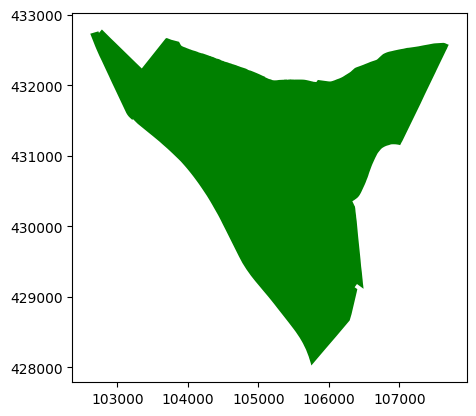

In [32]:
Alblasserdam_gdf = gpd.read_file(proces_data_dir / "alblasserdam_shape.geojson")
Alblasserdam_gdf.plot(color='green')

* collections → collection metadata → items → parameters.
* ga naar de landing page, nr 6: ""The JSON representation of the list of all data layers (collections) 
served from this endpoint" Klik daarop. Dan kom je op https://api.pdok.nl/cbs/wijken-en-buurten-2024/ogc/v1/collections.
* Er zijn hier drie collections: buurten/gemeenten/wijken. Hier staat: Bekijk collectie als JSON. 
* Daarin vind je dan weer: https://api.pdok.nl/cbs/wijken-en-buurten-2024/ogc/v1/collections/buurten
* Now you can fetch the actual data: https://api.pdok.nl/cbs/wijken-en-buurten-2024/ogc/v1/collections/buurten/items?f=json&limit=1000


### Ophalen boomhoogte rasterdata - niet meer nodig na random forest(?)

In [ ]:
# download zip file van boomhoogte data - EENMALIG UITVOEREN
url = "https://data.rivm.nl/data/alo/rivm_20240101_boomhoogte_2022.zip"
response = requests.get(url)
dest = raw_data_dir / "boom_hoogte.zip"

with open(dest, 'wb') as file:
    file.write(response.content)

#unpack zipfile and save
zip_path = raw_data_dir / "boom_hoogte_kaart_nl.zip"    #unzip
extract_dir = raw_data_dir / "boom_hoogte"              #destination path
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:               #write unzipped to destination
    z.extractall(extract_dir)

In [ ]:
#bomen kaart openen en snijden met gemeentevector - EENMALIG UITVOEREN VOOR EEN GEMEENTE
boom_raster_path = raw_data_dir / "boom_hoogte" / "rivm_20240101_boomhoogte_2022.tif"   
proces_data_dir.mkdir(parents=True, exist_ok=True)  #save folder

#load and inspect raster
with rio.open(boom_raster_path) as boom_raster:
    print(boom_raster.crs)
    print(boom_raster.count)
    print(boom_raster.meta)

    # Extract geometry from GeoDataFrame
    geom_alblas = [json.loads(Alblasserdam_gdf.to_json())["features"][0]["geometry"]]

    #clip raster to Alblasserdam
    out_image, out_transform = mask(
        boom_raster,
        shapes=geom_alblas,
        crop=True
    )

    #prepare metadata - Copy and update metadata
    out_meta = boom_raster.meta.copy()
    out_meta.update({
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

# Output file path
tif_path_alblas_bomen = proces_data_dir / "alblasserdam_bomen.tif"

# Write clipped raster
with rio.open(tif_path_alblas_bomen, "w", **out_meta) as dst:
    dst.write(out_image)

# tif_path_alblas_bomen

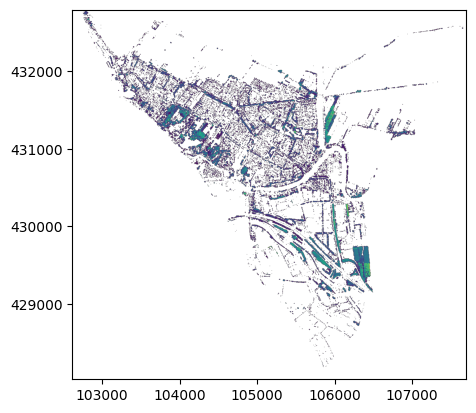

In [7]:
# checken of bomenkaart is geladen
tif_path_alblas_bomen = proces_data_dir / "alblasserdam_bomen.tif"
with rio.open(tif_path_alblas_bomen) as clipped_bomen_Alblasserdam:
    # print(clipped_bomen_Alblasserdam.meta)
    show(clipped_bomen_Alblasserdam)

### Data prep: RGB data, Infra data, DMS data

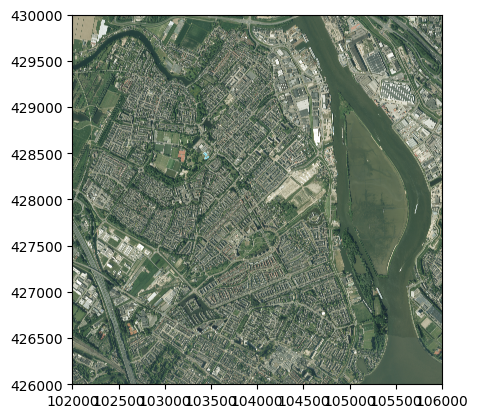

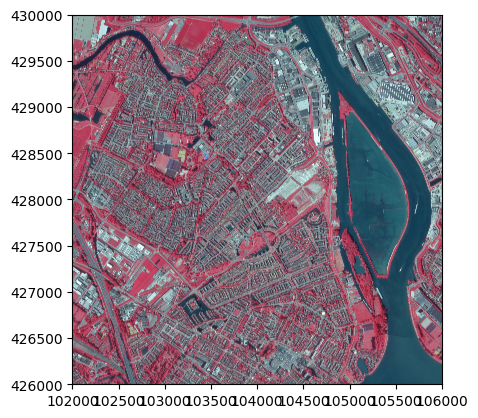

c:\Users\twand\Documents\Python\natural_capital\.venv\Lib\site-packages\matplotlib\colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


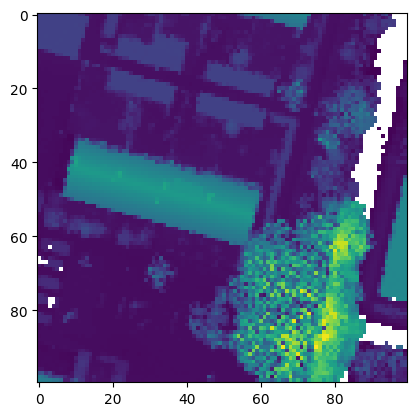

In [9]:
#testen of data succesvol kan worden ingeladen.
ortho_sample = "../data/raw/ortho_alblasserdam/2025_102000_430000_RGB_lrl.tif"
infra_sample = "../data/raw/infra_alblasserdam/2025_102000_430000_CIR_lrl.tif"
dsm_sample = "../data/raw/surface_model_05/R_38CN1.tif"

with rio.open(ortho_sample) as ortho:
    show(ortho)

with rio.open(infra_sample) as infra:
    show(infra)

with rio.open(dsm_sample) as dsm:
    my_window = Window(col_off=6600, row_off=6000, width=100, height=100)
    subset_masked = dsm.read(1, window=my_window, masked=True)
    show(subset_masked)

In [ ]:
#mergen van de vier ortho foto's (RGB en CIR) om ons totale gebied te dekken - EENMALIG UITVOEREN
tif_input_mosaic_rgb = raw_data_dir / "ortho_alblasserdam"
tif_output_mosaic_rgb = proces_data_dir / "RGB_tiles.tif"

tif_input_mosaic_infra = raw_data_dir / "infra_alblasserdam"
tif_output_mosaic_infra = proces_data_dir / "infra_tiles.tif"

merge_raster_to_mosaic(input_folder=tif_input_mosaic_rgb, 
                       output_file=tif_output_mosaic_rgb)


merge_raster_to_mosaic(input_folder=tif_input_mosaic_infra, 
                       output_file=tif_output_mosaic_infra)

#mergen van de twee hoogtemodellen (DTM-terrein en DSM-surface) om ons totale gebied te dekken - EENMALIG UITVOEREN
tif_input_mosaic_DTM05 = raw_data_dir / "terrain_model_05"     #EPSG:28992
tif_output_mosaic_DTM05 = proces_data_dir / "DTM05_tiles.tif"  #https://service.pdok.nl/rws/ahn/atom/dtm_05m.xml

tif_input_mosaic_DSM05 = raw_data_dir / "surface_model_05"     #EPSG:28992
tif_output_mosaic_DSM05 = proces_data_dir / "DSM05_tiles.tif"  #https://service.pdok.nl/rws/ahn/atom/dsm_05m.xml

merge_raster_to_mosaic(input_folder=tif_input_mosaic_DTM05, 
                       output_file=tif_output_mosaic_DTM05,
                       nodata=-9999.0)

merge_raster_to_mosaic(input_folder=tif_input_mosaic_DSM05, 
                       output_file=tif_output_mosaic_DSM05,
                       nodata=-9999.0)


Shape van subset: (80, 80)


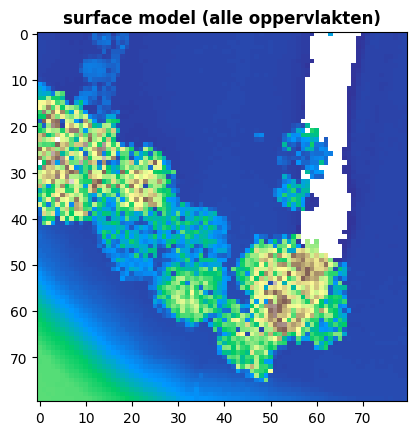

Shape van subset: (80, 80)


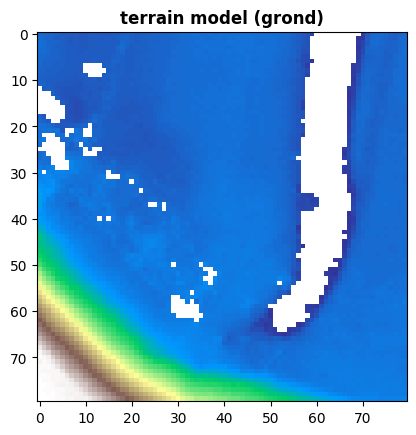

In [ ]:
#TEST of de DTM en DSM kaarten (merged/mosaic) goed worden ingeladen
tif_output_mosaic_DSM05 = proces_data_dir / "DSM05_tiles.tif"
tif_output_mosaic_DTM05 = proces_data_dir / "DTM05_tiles.tif"

with rio.open(tif_output_mosaic_DSM05) as src:
    my_window = Window(col_off=6600, row_off=6180, width=80, height=80)
    subset_masked = src.read(1, window=my_window, masked=True)

    print(f"Shape van subset: {subset_masked.shape}")
    show(subset_masked, cmap='terrain', contour=False, title='surface model (alle oppervlakten)')

with rio.open(tif_output_mosaic_DTM05) as src:
    my_window = Window(col_off=6600, row_off=6180, width=80, height=80)
    subset_masked = src.read(1, window=my_window, masked=True)

    print(f"Shape van subset: {subset_masked.shape}")
    show(subset_masked, cmap='terrain', contour=False, title='terrain model (grond)')

In [ ]:
#Berekenen van normalized DSM - EENMALIG UITVOEREN
# tif_output_mosaic_DSM05 = proces_data_dir / "DSM05_tiles.tif"
# tif_output_mosaic_DTM05 = proces_data_dir / "DTM05_tiles.tif"

# 1. Lees DSM (Het Oppervlak / Ruw)
with rio.open(tif_output_mosaic_DSM05) as src_dsm:
    dsm_data = src_dsm.read(1, masked=True)  
    out_meta = src_dsm.profile.copy()       # Kopieer metadata van de DSM voor de nieuwe nDSM laag

# 2. Lees DTM (Het Maaiveld / Kaal)
with rio.open(tif_output_mosaic_DTM05) as src_dtm:
    dtm_data = src_dtm.read(1, masked=True)

# 3. Bereken nDSM (Oppervlak - Maaiveld)
ndsm_data = dsm_data - dtm_data

# 4. Update de metadata
out_meta.update({
    "driver": "GTiff",
    "dtype": 'float32',       # Zeker weten dat we floats opslaan
    "nodata": -9999.0         # NoData waarde
})

tif_output_mosaic_ndsm = proces_data_dir / "nDSM_full.tif"

# 5. Schrijf het bestand weg
with rio.open(tif_output_mosaic_ndsm, "w", **out_meta) as dst:
    dst.write(ndsm_data, 1)

print(f"Succesvol opgeslagen: {tif_output_mosaic_ndsm}")

Succesvol opgeslagen: C:\Users\twand\Documents\Python\natural_capital\data\processed\nDSM_full.tif


--- Statistieken nDSM Subset ---
Minimale hoogte: -0.14 m
Maximale hoogte: 15.24 m
Gemiddelde hoogte: 1.41 m


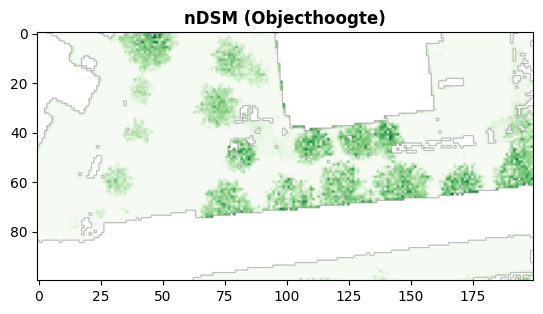

In [118]:
#TEST of nDSM werkt
tif_output_mosaic_ndsm = proces_data_dir / "nDSM_full.tif"
my_window = Window(col_off=9450, row_off=11850, width=200, height=100) #klein stuk van de kaart inladen
with rio.open(tif_output_mosaic_ndsm) as src_ndsm:
    subset = src_ndsm.read(1, window=my_window, masked=True)

    print(f"--- Statistieken nDSM Subset ---")
    print(f"Minimale hoogte: {subset.min():.2f} m")
    print(f"Maximale hoogte: {subset.max():.2f} m")
    print(f"Gemiddelde hoogte: {subset.mean():.2f} m")
    
    show(subset, cmap='Greens', title='nDSM (Objecthoogte)')

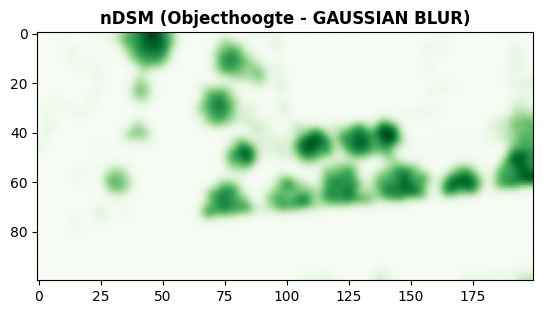

In [21]:
from scipy.ndimage import gaussian_filter
tif_output_mosaic_ndsm = proces_data_dir / "nDSM_full.tif"
my_window = Window(col_off=9450, row_off=11850, width=200, height=100) #klein stuk van de kaart inladen
with rio.open(tif_output_mosaic_ndsm) as src_ndsm:
    subset_masked = src_ndsm.read(1, window=my_window, masked=True)
    subset_filled = subset_masked.filled(0)
    height_blurred = gaussian_filter(subset_filled, sigma=2)
    show(height_blurred, cmap='Greens', title='nDSM (Objecthoogte - GAUSSIAN BLUR)')

In [72]:
#Berekenen van GAUSSIAN DSM - EENMALIG UITVOEREN
tif_output_mosaic_ndsm = proces_data_dir / "nDSM_full.tif"
tif_output_mosaic_ndsm_gaus = proces_data_dir / "nDSM_gaus_sig2_b5.tif"

def gaussian_blur_filter(ndm_input_path, gaussian_output_path, sigma=2, buffer=5):

    # 1. Lees DSM (Het Oppervlak / Ruw)
    with rio.open(ndm_input_path) as src_ndsm:

        out_meta = src_ndsm.meta.copy()
        out_meta.update({
            "dtype": "float32",
            "compress": "lzw",   
            "tiled": True,       
            "blockxsize": 256,
            "blockysize": 256
        }) 

        windows_list = list(src_ndsm.block_windows(1))
        totaal_blokken = len(windows_list)

        with rio.open(gaussian_output_path, "w", **out_meta) as dst:
            for i, (block_index, venster) in enumerate(windows_list):

                padded_window = Window(
                    venster.col_off - buffer,
                    venster.row_off - buffer,
                    venster.width + 2*buffer,
                    venster.height + 2*buffer
                )

                img_padded = src_ndsm.read(1, window=padded_window, boundless=True, fill_value=0)
                img_padded[img_padded < -100] = 0
                img_padded = np.nan_to_num(img_padded, nan=0.0)

                blurred_padded = gaussian_filter(img_padded, sigma=sigma)
                blurred_padded[blurred_padded < 0] = 0

                final_block = blurred_padded[buffer:-buffer, buffer:-buffer]

                dst.write(final_block.astype('float32'), window=venster, indexes=1)

                if i % 100 == 0:
                    print(f"Blok {i+1}/{totaal_blokken} verwerkt...", end='\r')



    print(f"Succesvol opgeslagen: {tif_output_mosaic_ndsm_gaus}")

### NDVI kaartlaag maken

Aantal bands: 3
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 32000, 'height': 32000, 'count': 3, 'crs': CRS.from_wkt('PROJCS["Amersfoort / RD New",GEOGCS["Amersfoort",DATUM["Amersfoort",SPHEROID["Bessel 1841",6377397.155,299.1528128,AUTHORITY["EPSG","7004"]],AUTHORITY["EPSG","6289"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4289"]],PROJECTION["Oblique_Stereographic"],PARAMETER["latitude_of_origin",52.1561605555556],PARAMETER["central_meridian",5.38763888888889],PARAMETER["scale_factor",0.9999079],PARAMETER["false_easting",155000],PARAMETER["false_northing",463000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","28992"]]'), 'transform': Affine(0.25, 0.0, 102000.0,
       0.0, -0.25, 434000.0)}
pixelgrootte: 0.25
Aantal bands: 3
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 32000, 'height': 32000, 'count': 3, 'crs': C

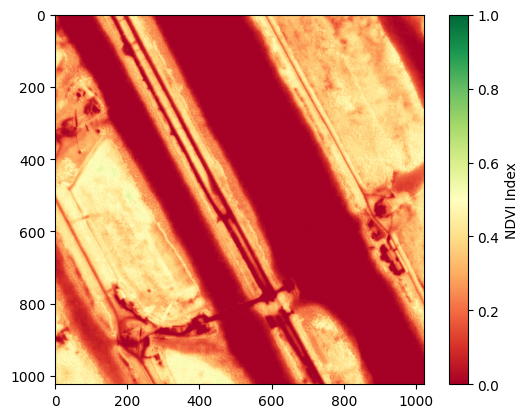

In [23]:
#CHECK of de berekening werkt
tif_output_mosaic_rgb = proces_data_dir / "RGB_tiles.tif"
tif_output_mosaic_infra = proces_data_dir / "infra_tiles.tif"

my_window = Window(col_off=6000, row_off=3000, width=1024, height=1024)

with rio.open(tif_output_mosaic_rgb) as src:
    print(f"Aantal bands: {src.count}")
    print(src.meta)
    red = src.read(1, window=my_window, masked=True).astype('float32')    #Band 1=R, 2=G, 3=B
    # show(red, title='red band ')
    print(f'pixelgrootte: {src.res[0]}')

with rio.open(tif_output_mosaic_infra) as src:
    print(f"Aantal bands: {src.count}")
    print(src.meta)
    nir = src.read(1, window=my_window, masked=True).astype('float32')
    # show(red, title='NIR band ')
    print(f'pixelgrootte: {src.res[0]}')


ndvi = (nir - red) / (nir + red + 1e-10)
# plt.imshow(ndvi, cmap='RdYlGn')
plt.imshow(ndvi, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(label='NDVI Index')




Minimale waarde: -0.26
Maximale waarde: 0.69
Gemiddelde gemiddelde: 0.16


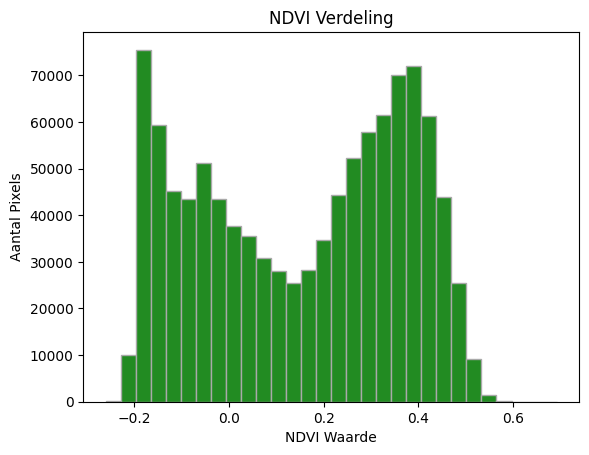

In [24]:
#check of de plots kloppen van de groenmaat (NDVI)
#graslanden of struikgewassen een NDVI waarde tussen de 0,2 en 0,4
#Bosvegetatie of hoogproductieve akkerbouw komen overeen met NDVI waardes hoger dan 0,4
#https://medium.com/@apratimonline/deep-dive-into-unsupervised-classification-of-satellite-images-k-means-pca-and-spectral-indices-442a5dc23219
print(f"Minimale waarde: {ndvi.min():.2f}")
print(f"Maximale waarde: {ndvi.max():.2f}")
print(f"Gemiddelde gemiddelde: {ndvi.mean():.2f}")
plt.hist(ndvi.compressed(), bins=30, color='forestgreen', edgecolor='darkgrey') # .compressed() is handig bij masked arrays: het verwijdert de NoData pixels
plt.title('NDVI Verdeling')
plt.xlabel('NDVI Waarde')
plt.ylabel('Aantal Pixels')
plt.show()

In [ ]:
#De volledige NDVI berekenen voor het hele gebied - EENMALIG
tif_output_mosaic_rgb = proces_data_dir / "RGB_tiles.tif"
tif_output_mosaic_infra = proces_data_dir / "infra_tiles.tif"

with rio.open(tif_output_mosaic_rgb) as src:
    new_meta = src.meta.copy()

    print(f"Aantal bands: {src.count}")
    print(src.meta)

    red = src.read(1, masked=True).astype('float32')    #Band 1=R, 2=G, 3=B
    show(red, title='red band ')

with rio.open(tif_output_mosaic_infra) as src:
    
    print(f"Aantal bands: {src.count}")
    print(src.meta)

    nir = src.read(1, masked=True).astype('float32')
    show(nir, title='NIR band ')


ndvi = (nir - red) / (nir + red + 1e-10)
plt.imshow(ndvi, cmap='RdYlGn')

new_meta.update({
    "driver": "GTiff",
    "dtype": "float32",     
    "count": 1,             
    "nodata": -9999,        # Definieer NoData waarde
    "compress": "lzw"       
})

tif_output_NDVI_0008m = proces_data_dir / "NDVI_008m.tif"

# 5. Schrijf het bestand weg
with rio.open(tif_output_NDVI_0008m, "w", **new_meta) as dst:
    dst.write(ndvi.filled(-9999).astype('float32'), 1)

print(f"Succesvol opgeslagen: {tif_output_NDVI_0008m}")

Aantal bands: 3
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 32000, 'height': 32000, 'count': 3, 'crs': CRS.from_wkt('PROJCS["Amersfoort / RD New",GEOGCS["Amersfoort",DATUM["Amersfoort",SPHEROID["Bessel 1841",6377397.155,299.1528128,AUTHORITY["EPSG","7004"]],AUTHORITY["EPSG","6289"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4289"]],PROJECTION["Oblique_Stereographic"],PARAMETER["latitude_of_origin",52.1561605555556],PARAMETER["central_meridian",5.38763888888889],PARAMETER["scale_factor",0.9999079],PARAMETER["false_easting",155000],PARAMETER["false_northing",463000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","28992"]]'), 'transform': Affine(0.25, 0.0, 102000.0,
       0.0, -0.25, 434000.0)}


### Upscalen naar zelfde niveau

In [ ]:
#resample RGB
resample_raster(proces_data_dir / "RGB_tiles.tif", proces_data_dir / "RGB_05m.tif")

#resample NDVI
resample_raster(proces_data_dir / "NDVI_008m.tif", proces_data_dir / "NDVI_05m.tif") #eigenlijk pas NDVI berekenen nadat brondata is geresampled.

#resample infra
resample_raster(proces_data_dir / "infra_tiles.tif", proces_data_dir / "infra_05m.tif")

Gereed: RGB_05m.tif is nu 0.5m resolutie.
Gereed: NDVI_05m.tif is nu 0.5m resolutie.
Gereed: infra_05m.tif is nu 0.5m resolutie.


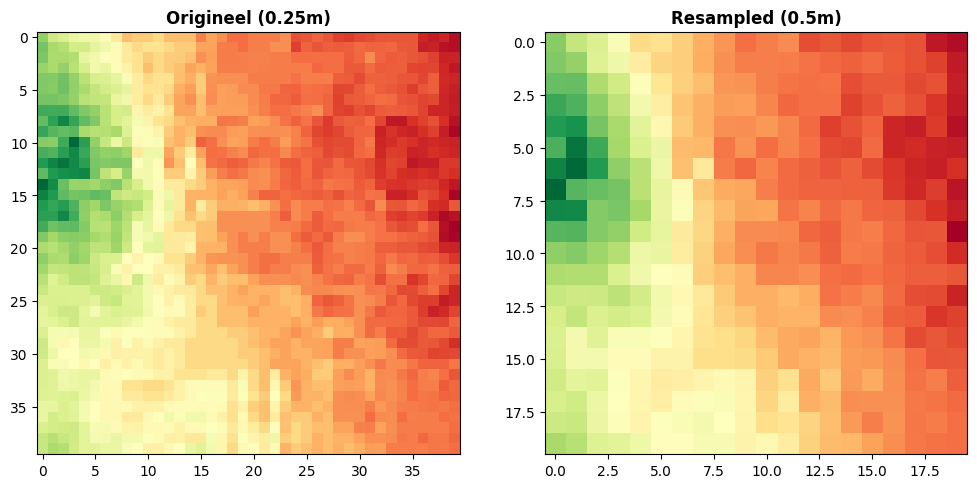

--- Statistiek Vergelijking (Subset) ---
Origineel - Min: -0.13, Max: 0.21, Mean: -0.01
Resampled - Min: -0.12, Max: 0.19, Mean: -0.01


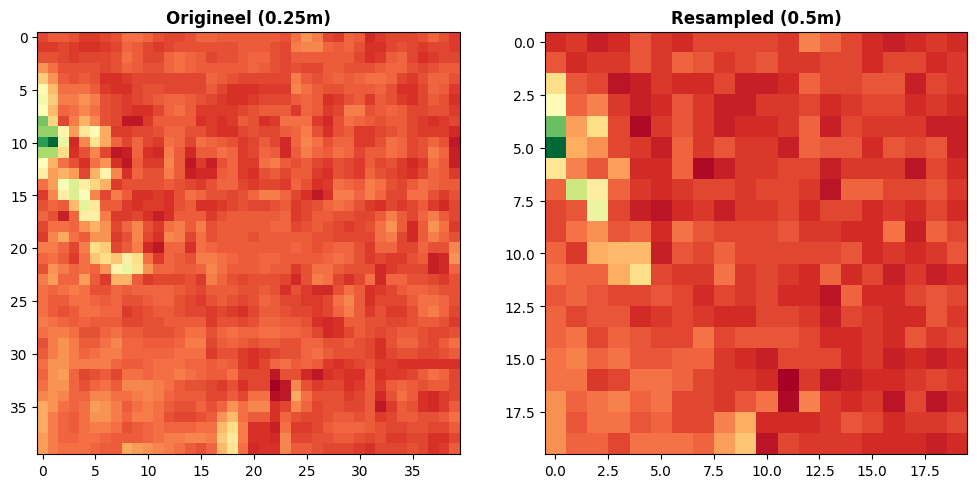

--- Statistiek Vergelijking (Subset) ---
Origineel - Min: 49.00, Max: 107.00, Mean: 59.18
Resampled - Min: 53.00, Max: 96.00, Mean: 59.29


In [ ]:
# CHECK Resample 
check_resampling(proces_data_dir / "NDVI_008m.tif", proces_data_dir / "NDVI_05m.tif")
check_resampling(proces_data_dir / "RGB_tiles.tif", proces_data_dir / "RGB_05m.tif")

In [24]:
with rio.open(proces_data_dir / "infra_05m.tif") as src:
    print(f"Aantal bands: {src.count}")      # Moet 3 zijn
    print(f"Bands: {src.indexes}")           # Moet (1, 2, 3) zijn
    print(f"Data type: {src.dtypes[0]}")     # Waarschijnlijk 'uint8' (0-255)

Aantal bands: 3
Bands: (1, 2, 3)
Data type: uint8


In [41]:
# ALLE RASTERS (ZELFDE RESOLUTIE 0.5M) STACKEN TOT ÉÉN LAAG
stack_path = proces_data_dir / "training_stack_05m_v2.tif"
create_feature_stack(
    stack_path,
    proces_data_dir / "nDSM_full.tif",
    proces_data_dir / "nDSM_gaus_sig2_b5.tif",
    proces_data_dir / "NDVI_05m.tif",
    proces_data_dir / "RGB_05m.tif",
    proces_data_dir / "infra_05m.tif",
    proces_data_dir / "RGB_texture_entropy_fast.tif",
    proces_data_dir / "RGB_texture_std_fast.tif"
)

Lagen inlezen (16k x 16k)...
nDSM uitlijnen op de rest...
Gelukt. Stack opgeslagen: training_stack_05m_v2.tif
Vorm van de stack: (9, 16000, 16000)


### Clip alle inputrasters naar gemeenteshape (nog even niet. Eerst gehele kaartlaag)

band names:('nDSM', 'nDSM_Gaussian', 'NDVI', 'Red', 'Green', 'Blue', 'NIR', 'entropy', 'texture')
input raster is clipped by    code  gemeentenaam                                           geometry
0  0482  Alblasserdam  MULTIPOLYGON (((105906.013 428208.799, 105905.....
Saved as: C:\Users\twand\Documents\Python\natural_capital\data\processed\alblasserdam_testing_stack_v2.tif
preview:
Preview van Band 1 (van de 9 bands):


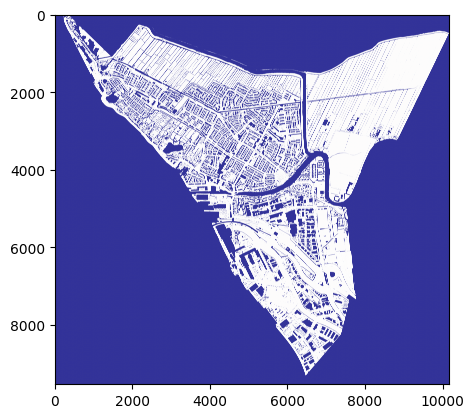

In [42]:
training_data_input = proces_data_dir / "training_stack_05m_v2.tif"
alblasserdam_shape = proces_data_dir / "alblasserdam_shape.geojson"
alblasserdam_testing_stack = proces_data_dir / "alblasserdam_testing_stack_v2.tif"

clip_raster_to_shape(input_raster_folder=training_data_input,
                     gemeente_geometry=Alblasserdam_gdf,
                     output_name=alblasserdam_testing_stack)

# with rio.open(alblasserdam_rgb) as clipped_infra_alblas:
#     # print(clipped_bomen_Alblasserdam.meta)
#     show(clipped_infra_alblas)

### Random forest model maken
* Er is geen goede bomenkaart op gemeenteniveau. Enkel grote gemeentes hebben accurate data van hun bomenbestand. Daarom, o.b.v. diverse type satellietbeelden kunnen we een inferentie doen van welke pixels 'boom' zijn en welke niet.
* Hiervoor moet eerst trainingsdata worden gelabeld in Qgis zodat het model wat voorbeelden heeft. 
* Vervolgens inferentie van 'Boompixels' die we schatten met RFM. Vervolgens pixels samenvoegen tot 'boom' eenheden

In [147]:
class_cols = ['boom', 'gras', 'gebouw', 'water_weg']

In [43]:
training_df = maak_training_dataset_tiled(
    raster_path=proces_data_dir / "training_stack_05m_v2.tif",
    vector_path=external_data_dir / "bomenlabels_15022026.gpkg", #de polygonen/vectors zijn in QGIS gelabelled
    output_csv_path=proces_data_dir / "bomen_training_dataset15022026.csv"
)

Oud bestand verwijderd: C:\Users\twand\Documents\Python\natural_capital\data\processed\bomen_training_dataset15022026.csv
Start met het verwerken van tegels (tiles)...


C:\Users\twand\AppData\Local\Temp\ipykernel_4320\1328066833.py:25: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  vector_data['label_naam'] = vector_data[kolom_namen].astype(float).idxmax(axis=1) #pakt de naam van de kolom die de hoogste waarde heef


De dataset is opgeslagen als: C:\Users\twand\Documents\Python\natural_capital\data\processed\bomen_training_dataset15022026.csv


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
import pandas as pd

In [45]:
#inladen trainingsdata
training_csv = proces_data_dir / "bomen_training_dataset15022026.csv"
training_df = pd.read_csv(training_csv)

In [46]:
#Beschrijvende statistiek en paar samples bekijken
print(training_df.shape)
print(training_df.sample(5))
print(training_df.label.value_counts())

(3478083, 11)
              nDSM  nDSM_Gaussian      NDVI    Red  Green   Blue    NIR  \
987800   13.731600      12.190230  0.491695   67.0   91.0   69.0  195.0   
883012    0.000000       0.000000  0.480199   67.0   97.0   71.0  192.0   
1399525   2.789200       5.651793  0.528261   54.0   81.0   66.0  173.0   
2273587  25.247499      15.520618  0.227546  113.0  127.0  101.0  180.0   
501625    9.484400      14.694951  0.523771   52.0   79.0   64.0  166.0   

          entropy    texture  label_id label  
987800   4.090234   7.320064         1  boom  
883012   3.607475   3.729574         2  gras  
1399525  4.168326   7.439675         1  boom  
2273587  4.047299  17.688665         1  boom  
501625   4.090234   6.636680         1  boom  
label
water_weg    2356704
gebouw        461335
gras          460205
boom          199839
Name: count, dtype: int64


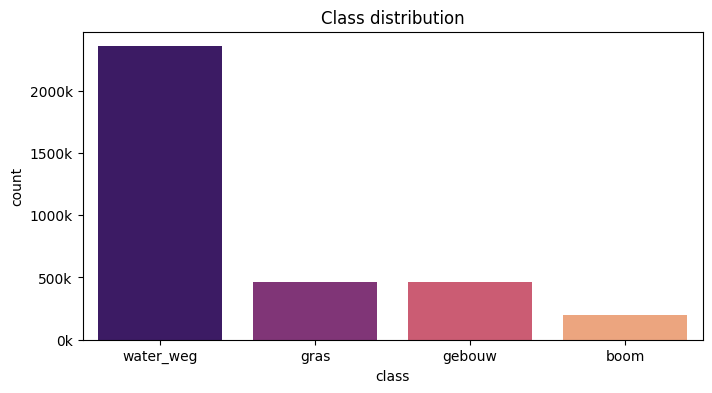

In [47]:
#class imbalance onderzoeken
plt.figure(figsize=(8,4))

ax = sns.countplot(x='label', data=training_df, hue='label', palette='magma')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k'))

plt.title('Class distribution')
plt.xlabel('class')
plt.ylabel('count')
plt.show()


In [48]:
#resample class imbalance
def manual_undersample(df, label_col='label_id'):
    min_size = training_df[label_col].value_counts().min()
    print(f'minimum size for balanced dataset is {min_size} samples')
    balanced_df = training_df.groupby(label_col).sample(n=min_size, random_state=87)
    
    return balanced_df.sample(frac=1).reset_index(drop=True)

df_balanced = manual_undersample(training_df)
print(df_balanced.groupby(['label', 'label_id']).size())

minimum size for balanced dataset is 199839 samples
label      label_id
boom       1           199839
gebouw     3           199839
gras       2           199839
water_weg  4           199839
dtype: int64


In [49]:
X = df_balanced.drop(['label_id', 'label'], axis=1)
y = df_balanced['label_id']

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [51]:
#split train-test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
#transformeer kolumn namen naar werkbare lijst voor Scikit-learn pipeline ColumnTransformer
numeric_features = X_train.columns.tolist()
print(numeric_features)

['nDSM', 'nDSM_Gaussian', 'NDVI', 'Red', 'Green', 'Blue', 'NIR', 'entropy', 'texture']


In [53]:
#imputer instellen voor missende data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
    ])

In [54]:
#preprocessor pipeline maken
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
        ])

In [55]:
#pipeline bouwen
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(random_state=87))
])

In [56]:
#model runnen en beste estimators kiezen voor final model
cv = KFold(n_splits=5, shuffle=True, random_state=5)

param_grid = {
    'classifier__learning_rate': [0.1],                 # 0.1 is de standaard, 0.05 is voorzichtiger
    'classifier__max_iter': [300],                 # Meer iteraties is vaak beter bij boosting
    'classifier__max_leaf_nodes': [100, 120],             # 31 is default, 63 maakt complexere bomen
    'classifier__l2_regularization': [0.05, 0.1]           # Helpt tegen overfitting bij nDSM uitschieters
}

estimator = GridSearchCV(pipe,
                          param_grid,
                          scoring='accuracy',
                          cv=5,
                          n_jobs=4,
                          verbose=3)

#Fitten en Scoren
estimator.fit(X_train, y_train)
print(f'beste params:{estimator.best_params_}')
print(f'test score: {estimator.score(X_test, y_test)} ' )

Fitting 5 folds for each of 4 candidates, totalling 20 fits
beste params:{'classifier__l2_regularization': 0.1, 'classifier__learning_rate': 0.1, 'classifier__max_iter': 300, 'classifier__max_leaf_nodes': 120}
test score: 0.9889599179343475 


In [57]:
best_model = estimator.best_estimator_
y_pred = best_model.predict(X_test)

In [58]:
result = pd.DataFrame(estimator.cv_results_)
result.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__l2_regularization,param_classifier__learning_rate,param_classifier__max_iter,param_classifier__max_leaf_nodes,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,29.130113,2.845654,3.410461,0.263196,0.05,0.1,300,100,"{'classifier__l2_regularization': 0.05, 'class...",0.988514,0.989015,0.988671,0.989366,0.988835,0.988880,0.000295,2
1,30.672806,3.535012,3.347248,0.394327,0.05,0.1,300,120,"{'classifier__l2_regularization': 0.05, 'class...",0.988499,0.989155,0.988459,0.989187,0.988975,0.988855,0.000316,3
2,31.433334,3.858634,3.523961,0.364256,0.10,0.1,300,100,"{'classifier__l2_regularization': 0.1, 'classi...",0.988459,0.989241,0.988452,0.989179,0.988733,0.988813,0.000340,4
3,29.925202,3.691071,2.889699,0.470368,0.10,0.1,300,120,"{'classifier__l2_regularization': 0.1, 'classi...",0.988811,0.988897,0.988929,0.989257,0.988819,0.988943,0.000163,1


In [59]:
performance_table = result.groupby(['param_classifier__learning_rate', 'param_classifier__max_iter', 'param_classifier__max_leaf_nodes'])[['mean_test_score']].mean()
performance_table

mean_test_score
param_classifier__learning_rate param_classifier__max_iter param_classifier__max_leaf_nodes                 
0.1                             300                        100                                      0.988846
                                                           120                                      0.988899

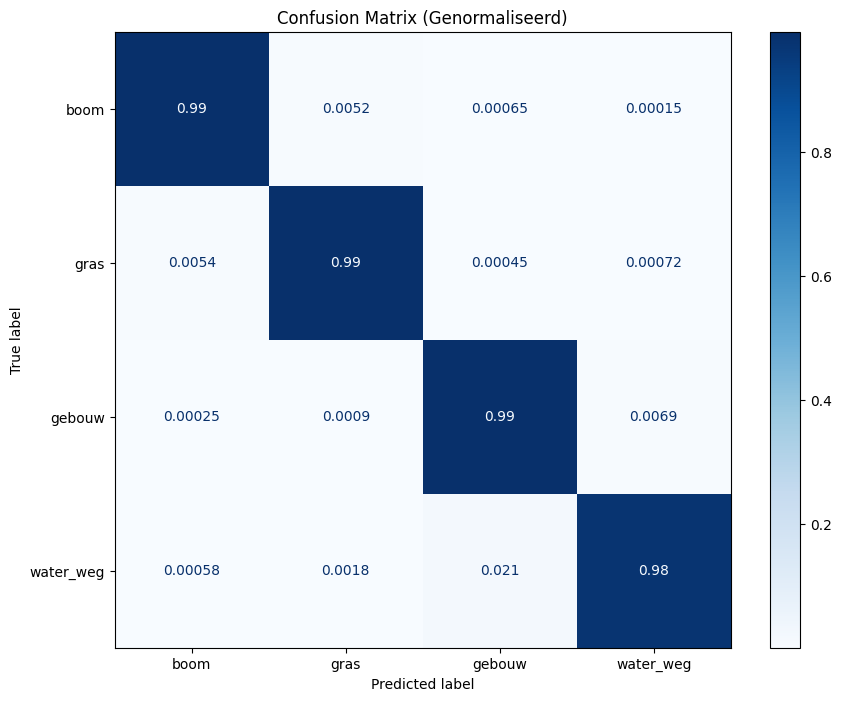

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Maak de plot direct vanuit het model
fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_estimator(
    best_model, 
    X_test, 
    y_test, 
    display_labels=['boom', 'gras', 'gebouw', 'water_weg'], # Of gebruik je dict: num_to_name.values()
    cmap='Blues',
    normalize='true', # 'true' toont percentages, laat weg voor aantallen
    ax=ax
)

plt.title("Confusion Matrix (Genormaliseerd)")
plt.show()

### Twijfelgevallen analyse

In [61]:
print(best_model.classes_)
num_to_label = {1: 'boom', 2: 'gras', 3:'gebouw', 4: 'water_weg'}
target_id = best_model.classes_[0]
target_label = num_to_label[target_id]
print(f"Index 1 in predict_proba hoort bij ID {target_id}, oftewel: {target_label}")
print(X_test.columns)

[1 2 3 4]
Index 1 in predict_proba hoort bij ID 1, oftewel: boom
Index(['nDSM', 'nDSM_Gaussian', 'NDVI', 'Red', 'Green', 'Blue', 'NIR',
       'entropy', 'texture'],
      dtype='object')


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

#nieuwe DF maken met probabilities
boom_evaluatie_df = X_test.copy()

boom_evaluatie_df['ground_truth_id'] = y_test.values
boom_evaluatie_df['voorspelt_id'] = y_pred
boom_evaluatie_df['kans_boom'] = best_model.predict_proba(X_test)[:, 0] 

#labels terugplakken (nu codes. Zie num_to_label,)
boom_evaluatie_df['ground_truth'] = boom_evaluatie_df['ground_truth_id'].map(num_to_label)
boom_evaluatie_df['voorspelt'] = boom_evaluatie_df['voorspelt_id'].map(num_to_label)
boom_evaluatie_df['correct'] = np.where(boom_evaluatie_df['ground_truth'] != boom_evaluatie_df['voorspelt'], 'slecht_voorspelt', 'goed_voorspelt')

# Filteren op twijfelgevallen
twijfelgevallen = boom_evaluatie_df[boom_evaluatie_df['kans_boom'].between(0.45, 0.65)]
print(f"Aantal twijfelgevallen: {len(twijfelgevallen)}")

#filteren op twijfelgevallen enkel slecht voorpelde
twijfelgevallen_slecht = boom_evaluatie_df.loc[
    (boom_evaluatie_df['kans_boom'].between(0.45, 0.65)) & 
    (boom_evaluatie_df['correct'] == 'slecht_voorspelt')
]
print(f"Aantal twijfelgevallen (slecht): {len(twijfelgevallen_slecht)}")

features_to_check = ['nDSM', 'NDVI', 'kans_boom'] 
print("\nGemiddelde waardes van twijfelgevallen:")
print(twijfelgevallen_slecht[features_to_check].mean())
print("\nCheck van eerste 10 twijfelgevallen:")
print(twijfelgevallen_slecht[features_to_check + ['ground_truth', 'voorspelt', 'correct']].sample(5))


analysis = twijfelgevallen_slecht.groupby(['ground_truth', 'voorspelt']).agg(
    count=('correct', 'size'),
    avg_NDSM=('nDSM', 'mean'),
    avg_NDVI=('NDVI', 'mean'),
    avg_NDSM_gaus=('nDSM_Gaussian', 'mean')
)

print(analysis)



Aantal twijfelgevallen: 146
Aantal twijfelgevallen (slecht): 71

Gemiddelde waardes van twijfelgevallen:
nDSM         1.573396
NDVI         0.326014
kans_boom    0.549216
dtype: float64

Check van eerste 10 twijfelgevallen:
          nDSM      NDVI  kans_boom ground_truth voorspelt           correct
707786  3.1407  0.017062   0.485637         boom    gebouw  slecht_voorspelt
101385  0.0000  0.352204   0.518736         gras      boom  slecht_voorspelt
120801  1.1183  0.540220   0.511155         gras      boom  slecht_voorspelt
76823      NaN  0.315216   0.598861         gras      boom  slecht_voorspelt
416750     NaN  0.352478   0.556121    water_weg      boom  slecht_voorspelt
                        count  avg_NDSM  avg_NDVI  avg_NDSM_gaus
ground_truth voorspelt                                          
boom         gebouw         1  3.140700  0.017062       1.194595
             gras          12  4.874734  0.327530       0.907167
             water_weg      1       NaN  0.320076     

### Beste model maken en opslaan

In [63]:
import joblib
model_path = home_dir / "src"

final_model = estimator.best_estimator_
model_bestandsnaam = model_path / "hgbc_model_drechtsteden_v2.pkl"
joblib.dump(final_model, model_bestandsnaam)

print(f'bestand opgeslagen in {model_path}' )

bestand opgeslagen in C:\Users\twand\Documents\Python\natural_capital\src


### Bomen herkennen -  inferentie op Alblasserdam

In [65]:
import rasterio as rio
import joblib
import numpy as np
import pandas as pd
from pathlib import Path

model_path = home_dir / "src"
hgbc_from_joblib = joblib.load(model_path / "hgbc_model_drechtsteden_v2.pkl")
alblasserdam_testing_stack = proces_data_dir / "alblasserdam_testing_stack_v2.tif"
output_11_layers = proces_data_dir / "Alblasserdam_Inference_Stack_11L.tif"

with rio.open(alblasserdam_testing_stack) as src:
    feature_namen = src.descriptions
    print(f'feature namen: {feature_namen}')
    
    # --- CHECK 1: KLASSEN CONTROLEREN ---
    print(f"Beschikbare klassen in model: {hgbc_from_joblib.classes_}")
    
    # Bepaal boom-index veilig
    try:
        boom_class_index = list(hgbc_from_joblib.classes_).index(1)
        print(f'boom class index: {boom_class_index}')
    except ValueError:
        print("LET OP: Klasse '1' niet gevonden in model! Check je model classes.")
        raise

    model_features = getattr(hgbc_from_joblib, 'feature_names_in_', None)
    print(f'model features: {model_features}')

    # --- CHECK 2: VOORBEREIDING VOORTGANG ---
    # We maken een lijst van de windows zodat we de totale lengte weten
    windows_list = list(src.block_windows(1))
    totaal_blokken = len(windows_list)
    print(f"Totaal aantal te verwerken blokken: {totaal_blokken}")

    # --- CHECK 3: METADATA & STRIPS FIX ---
    out_meta = src.meta.copy()
    out_meta.update({
        "count": 11,
        "dtype": "float32",
        "compress": "lzw",   # Aanrader: compressie aan (scheelt schijfruimte)
        "tiled": True,       # BELANGRIJK: Forceer tegels (geen strips)
        "blockxsize": 256,   # Standaard blokgrootte
        "blockysize": 256
    }) 
    
    print("Start inferentie...")
    
    with rio.open(output_11_layers, "w", **out_meta) as dst:
        output_namen = list(feature_namen) + ['Classificatie', 'Boom_Kans']
        
        # We itereren nu over de lijst die we eerder maakten
        for i, (block_index, venster) in enumerate(windows_list):
            
            # A. Lees blok
            img_block = src.read(window=venster)
            
            # Afmetingen pakken
            actual_height = img_block.shape[1]
            actual_width = img_block.shape[2]
            
            # B. Data voorbereiden
            pixels_np = img_block.reshape(src.count, -1).T 
            pixels_df = pd.DataFrame(pixels_np, columns=feature_namen)
            
            if model_features is not None:
                pixels_df = pixels_df[list(model_features)]

            # C. Voorspellen
            labels_1D = hgbc_from_joblib.predict(pixels_df).ravel()
            probas_all = hgbc_from_joblib.predict_proba(pixels_df)
            tree_probas_1D = probas_all[:, boom_class_index].ravel()

            # Reshape naar 2D voor dit blok
            labels_2D = labels_1D.reshape((actual_height, actual_width))
            tree_probas_2D = tree_probas_1D.reshape((actual_height, actual_width))

            # D. Schrijven
            dst.write(img_block.astype('float32'), window=venster, indexes=[1, 2, 3, 4, 5, 6, 7, 8 ,9])
            dst.write(labels_2D.astype('float32'), window=venster, indexes=10)
            dst.write(tree_probas_2D.astype('float32'), window=venster, indexes=11)
            
            # --- CHECK 4: VOORTGANG PRINT ---
            if i % 10 == 0 or i == totaal_blokken - 1: # Iets vaker updaten
                percentage = ((i + 1) / totaal_blokken) * 100
                print(f"Blok {i + 1} van {totaal_blokken} verwerkt ({percentage:.1f}%)", end='\r')
            
        # Namen instellen (kan pas na loop of tijdens, maakt niet uit)
        for i, naam in enumerate(output_namen):
            dst.set_band_description(i + 1, naam)

print("\nKlaar! Output is getiled en bevat 11 lagen.")

feature namen: ('nDSM', 'nDSM_Gaussian', 'NDVI', 'Red', 'Green', 'Blue', 'NIR', 'entropy', 'texture')
Beschikbare klassen in model: [1 2 3 4]
boom class index: 0
model features: ['nDSM' 'nDSM_Gaussian' 'NDVI' 'Red' 'Green' 'Blue' 'NIR' 'entropy'
 'texture']
Totaal aantal te verwerken blokken: 9533
Start inferentie...
Blok 9533 van 9533 verwerkt (100.0%)
Klaar! Output is getiled en bevat 11 lagen.


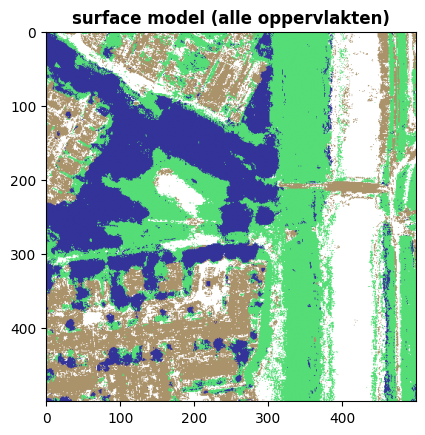

In [66]:
output_11_layers = proces_data_dir / "Alblasserdam_Inference_Stack_11L.tif"

with rio.open(output_11_layers) as src:
    my_window = Window(col_off=6000, row_off=2000, width=500, height=500)
    subset_masked = src.read(10, window=my_window, masked=True)
    show(subset_masked, cmap='terrain', contour=False, title='surface model (alle oppervlakten)')


### segmentatie van bomen

In [ ]:
#nieuwe Gaussian filter
gaussian_blur_filter(proces_data_dir / "nDSM_full.tif", 
                     proces_data_dir / "nDSM_gaus_sig15_b5.tif", 
                     sigma=1.5, 
                     buffer=5)

In [94]:
### gebruiken als de gehele stack in één keer gebruikt kan worden!
import pandas as pd
import numpy as np
import rasterio as rio
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import label
from scipy import ndimage as ndi
import geopandas as gpd
from shapely.geometry import shape
import rasterio.features
from scipy import ndimage as ndi
from scipy.ndimage import binary_closing, binary_fill_holes

bomen_raster_alblasserdam_path = proces_data_dir / "Alblasserdam_Inference_Stack_11L.tif"

with rio.open(bomen_raster_alblasserdam_path) as src:
    # inlezen
    name_to_index = {name: i+1 for i, name in enumerate(src.descriptions)}
    print(name_to_index)

    prob_map = src.read(name_to_index.get('Boom_Kans'))
    ndsm_gaus = src.read(name_to_index.get('nDSM_Gaussian'))

    transform = src.transform #bv. | 0.25, 0.00, 105430.00| Met de transform berekent Python tijdens het maken van de polygonen direct de echte coördinaten uit.
    crs = src.crs

    # boom masker maken. 
    # Buiten dit masker mag geen boom getekend worden.
    strenge_drempel = 0.50
    ruime_drempel = 0.20

    seed_mask = (prob_map >= strenge_drempel) & (ndsm_gaus > 3) 
    raw_growth_mask = (prob_map >= ruime_drempel) & (ndsm_gaus > 1.5)
    closed_mask = binary_closing(raw_growth_mask, structure=np.ones((3,3)), iterations=2)
    growth_mask = binary_fill_holes(closed_mask)

    print(f"Potentiële boom-pixels (ruim): {np.sum(growth_mask)}")
    print(f"Zekere boom-kernen (streng): {np.sum(seed_mask)}")

    # lokale minima (boomtoppen)
    coords = peak_local_max(ndsm_gaus, min_distance=9, labels=seed_mask) #minimaal 2 meter (4 pixels) uit elkaar
    
    # Maak een masker van alleen de puntjes (de seeds)
    local_maxi = np.zeros_like(ndsm_gaus, dtype=bool)
    local_maxi[tuple(coords.T)] = True

    #label de punten
    markers =ndi.label(local_maxi)[0]

    #watershed
    labels = watershed(-ndsm_gaus, markers, mask=growth_mask)
    print(f"Aantal bomen gevonden: {labels.max()}") 

    # 5. VECTORISEREN (Met filter voor 0!)
    print("Omzetten naar polygonen...")
    
    # We voegen 'if v > 0' toe. 
    # Dit zorgt dat de achtergrond (waarde 0) GEEN polygoon krijgt.
    results = (
        {'properties': {'boom_id': int(v)}, 'geometry': s}
        for i, (s, v) in enumerate(
            rasterio.features.shapes(labels.astype(np.int32), mask=growth_mask, transform=transform)
        )
        if v > 0  # <--- CRUCIALE FIX: Sla de achtergrond over!
    )

    geoms = list(results)
    gdf = gpd.GeoDataFrame.from_features(geoms)

    # CRS instellen
    if crs:
        gdf.set_crs(crs, inplace=True)
    else:
        gdf.set_crs(epsg=28992, inplace=True)

    # 6. HOOGTE BEREKENEN (Gecorrigeerd)
    print("Hoogtes berekenen per boom...")
    
    if not gdf.empty:
        boom_ids = gdf['boom_id'].values
        
        # FIX VOOR ROUND: Zet het resultaat eerst om naar een np.array
        # ndi.maximum geeft een lijst terug, en lijsten kunnen niet afronden.
        raw_heights = ndi.maximum(ndsm_gaus, labels=labels, index=boom_ids)
        gdf['max_height'] = raw_heights.astype(float).round(2)
        
        # De rest van de attributen
        gdf['omtrek_m'] = gdf.geometry.length.astype(float).round(2)
        gdf['area_m2'] = gdf.geometry.area.astype(float).round(2)

        #berekende attributen
        gdf['diameter'] = (gdf.geometry.length.astype(float).round(2)/1.57)**1.429
        
        
        # Filteren op grootte
        gdf_clean = gdf[gdf['area_m2'] > 3.0].copy()
    else:
        print("Geen bomen gevonden om te verwerken.")
        gdf_clean = gdf
    
    

    output_vector = proces_data_dir / "gedetecteerde_bomen_albasserdam_v14.gpkg"

    gdf_clean.to_file(output_vector, driver="GPKG")

    print(f"Polygonen opgeslagen in {output_vector}")

{'nDSM': 1, 'nDSM_Gaussian': 2, 'NDVI': 3, 'Red': 4, 'Green': 5, 'Blue': 6, 'NIR': 7, 'entropy': 8, 'texture': 9, 'Classificatie': 10, 'Boom_Kans': 11}
Potentiële boom-pixels (ruim): 2572662
Zekere boom-kernen (streng): 1679025
Aantal bomen gevonden: 6318
Omzetten naar polygonen...
Hoogtes berekenen per boom...
Polygonen opgeslagen in C:\Users\twand\Documents\Python\natural_capital\data\processed\gedetecteerde_bomen_albasserdam_v14.gpkg


## Synthetische boom creeëren

Omdat we werken op wijkniveau, en van individuele bomen niet weten welke soort het is. Creeëren we een fictieve boom die de verdeling van boomsoorten representeert uit deze regio. Hiervoor gebruiken we onder anderen het rappoort van Natuur & Milieu (2023).

Dit onderzoek maakte gebruik van data van 2,5 miljoen bomen in de openbare ruimte en verschaft ook een top 5 bomensoortenlijst per gemeente. Gemeente Dordrecht dient hier als representatieve gemeente voor Alblasserdam.

De fictieve boom bestaat in dit geval dus: 
* 12% uit Eik, 
* 7% uit Es,
* 5% uit Linde,
* 4% uit schietwilg,
* 4% uit gewone plataan.

We beginnen met boomhoogte (h) als enige 'harde' variabele (uit nDSM).Voor het berekenen van stamdiameter, kroonprojectie en kroonvolume gebruiken we dus gewogen coëfficiënten om vanuit de boomhoogte de andere variabelen mee uit te rekenen.

Risico: Een kleine meetfout kan dus al leiden tot grote afwijkingen tussen de theoretische berekeningen en de daadwerkelijke eigenschappen van de boom. Daarom gebruiken we bandbreedtes (Mean ± SE) om deze onzekerheid te uiten.


1. **Normaliseren van coefficienten**
We normaliseren de gewichten zodat ze samen 1.0 vormen op basis van de 32% geïdentificeerde bomen in Tabel 2 uit Pretzsch et al. (2015). De Mix-Weging:
- Type 1 (Groot/Breed): Linde + Plataan (5%+4%=9%) →w1​≈0.281
- Type 2 (Medium): Es + Wilg (7%+4%=11%) →w2​≈0.344
- Type 3 (Medium/Smal): Eik (12%) →w3​≈0.375
<br>

2. **Van Hoogte (h) naar Stamdiameter (d) <--> Hoogte-Diameter relatie**
- **αh_mix​ = 0.67** The species-specific allometric slope for open-grown trees, α. Geeft hoe snel de hoogte toeneemt ten opzichte van de diameter.Genormaliseerde Alblasserdam-Boom.

- **ah_mix​ = 0.36** De intercept: het punt waar de lijn de y-as snijdt. Het vertegenwoordigt de basisverhouding van de boomvorm.

- a legt de "startwaarde" of de basisproportie van de boom vast, terwijl de α bepaalt hoe die verhouding verandert naarmate de boom groter wordt.

3. **Van diameter (d) naar kroonradius (cr) <--> (Kroonradius relatie)**
- **α_cr_mix​ = 0.691**
- **a_cr_mix​=−0.945**

- Wederom intercept en hellingshoek hoe kroonradius opschaalt met diamter.

4. **Van diameter (d) naar kroonvolume (cv) <--> (Kroonvolume relatie)**
- **α_cv​ ≈ 1.7**
- **a_cv ​≈ 1.1 (let op: dit is ln(a), dus factor ≈3.0)**

### de berekeningen
- **Diameter (d)** = (h/e^ah_mix) ^ 1/αh_mix
- **Kroonradius (cr)** = (e^acr_mix) * d^αcr_mix --> kunnen ook daadwerkelijke radius gebruiken
- **kroonprojectie (cpa)** = π⋅cr^2
- **kroonvolume (cv)** = 3.00⋅d^1.7


In [132]:
## test_berekeningen
boom_hoogte_dummy = raw_heights[0:2]
boom_hoogte_dummy2 = 10
print(boom_hoogte_dummy)
print(type(raw_heights))

[4.435841  3.2423074]
<class 'numpy.ndarray'>


In [ ]:
#inladen boomvector
Alblasserdam_bomen_vector_path = proces_data_dir / "gedetecteerde_bomen_albasserdam_v14.gpkg"
bomen_vect = gpd.read_file(Alblasserdam_bomen_vector_path)
bomen_vect.head(5)

,boom_id,max_height,omtrek_m,area_m2,geometry
0,1,4.44,66.0,137.00,"POLYGON ((102791 432776.5, 102791 432776, 1027..."
1,5,3.24,18.0,7.75,"POLYGON ((102814 432758, 102814 432757, 102813..."
2,2,5.71,61.0,105.75,"POLYGON ((102800.5 432767, 102800.5 432766.5, ..."
3,3,6.41,49.0,99.75,"POLYGON ((102782 432761, 102782 432760.5, 1027..."
4,6,4.43,30.0,44.50,"POLYGON ((102801 432757.5, 102801 432756.5, 10..."


In [ ]:
# --- 1. Parameters (Pretzsch paper) ---
ah_mix, alphah_mix = 0.36, 0.67
acr_mix, alphacr_mix = -0.945, 0.691
ln_acv, alphacv = 1.1, 1.7
factor_cv = np.exp(ln_acv) # ≈ 3.00

# --- 2. Vectorberekening op de GDF ---
# A. Stamdiameter (d)
bomen_vect['diameter_cm'] = (bomen_vect['max_height'] / np.exp(ah_mix)) ** (1 / alphah_mix)

# B. Kroonradius (cr) 
# We kiezen: gebruik de GIS area als die er is, anders de theoretische formule
theoretical_cr = np.exp(acr_mix) * (bomen_vect['diameter_cm'] ** alphacr_mix)
observed_cr = np.sqrt(bomen_vect['area_m2'] / np.pi)

# Optie: GEOMETERIE voor de radius (is nauwkeuriger voor de huidige staat)
bomen_vect['kroonradius_m'] = observed_cr 

# C. Projectie (cpa) en Volume (cv)
bomen_vect['kroonprojectie_m2'] = np.pi * (bomen_vect['kroonradius_m'] ** 2)
bomen_vect['kroonvolume_m3'] = factor_cv * (bomen_vect['diameter_cm'] ** alphacv)

# D. Afronden voor de netheid in QGIS
cols_to_round = ['diameter_cm', 'kroonradius_m', 'kroonprojectie_m2', 'kroonvolume_m3']
bomen_vect[cols_to_round] = bomen_vect[cols_to_round].astype(float).round(2)

### Scenarios voor bandbreedte (voor later)

In [141]:
def bereken_boom_scenarios(gdf):
    # 1. Basis Parameters (Pretzsch Mix)
    ah_mix, alphah_mix = 0.36, 0.67
    acr_mix, alphacr_mix = -0.945, 0.691
    ln_acv, alphacv = 1.1, 1.7
    
    # 2. Bereken de 'Mean' waarden (Vectorized)
    h_m = gdf['max_height'].values
    d_m = (h_m / np.exp(ah_mix)) ** (1 / alphah_mix)
    
    # Gebruik GIS area voor de actuele radius
    cr_m = np.sqrt(gdf['area_m2'].values / np.pi)
    cpa_m = np.pi * (cr_m ** 2)
    cv_m = np.exp(ln_acv) * (d_m ** alphacv)

    # 3. Definieer SE factoren uit jouw tabel
    se_factors = {
        'Low (-1 SE)':  {'h': 0.90, 'd': 0.75, 'cr': 0.74, 'cpa': 0.48, 'cv': 0.48},
        'Mean':         {'h': 1.00, 'd': 1.00, 'cr': 1.00, 'cpa': 1.00, 'cv': 1.00},
        'High (+1 SE)': {'h': 1.10, 'd': 1.25, 'cr': 1.26, 'cpa': 1.52, 'cv': 1.52}
    }

    # 4. Maak de drie scenario-versies van de GDF
    scenarios = []
    for name, f in se_factors.items():
        s_gdf = gdf.copy()
        s_gdf['scenario'] = name
        s_gdf['h_final'] = (h_m * f['h']).round(2)
        s_gdf['d_cm'] = (d_m * f['d']).round(2)
        s_gdf['cr_m'] = (cr_m * f['cr']).round(2)
        s_gdf['cpa_m2'] = (cpa_m * f['cpa']).round(2)
        s_gdf['cv_m3'] = (cv_m * f['cv']).round(2)
        scenarios.append(s_gdf)

    # 5. Voeg alles samen (Long format: 3 rijen per boom)
    gdf_final = pd.concat(scenarios, ignore_index=True)
    return gdf_final

# Gebruik:
gdf_boom_bandbreedte = bereken_boom_scenarios(bomen_vect)

In [142]:
print(gdf_boom_bandbreedte.shape)
print(bomen_vect.shape)

(18669, 15)
(6223, 9)


https://medium.com/@apratimonline/deep-dive-into-unsupervised-classification-of-satellite-images-k-means-pca-and-spectral-indices-442a5dc23219

### Scoping out the main ecosystem services. Ophalen data van biofysieke flows van bomen:
* CO2 opslag
* waterretentie
* Luchtvervuiling opname
* geluidsreductie
* Aestethiek
* Recreationele waarde
* Lokaal microklimaat (afkoeling)


### Ophalen monetaire kentallen ecosysteemdiensten:
* CO2 opslag
* waterretentie
* Luchtvervuiling opname
* geluidsreductie
* Aestethiek
* Recreationele waarde
* Lokaal microklimaat (afkoeling)



In [19]:
BASE = "https://api.pdok.nl/cbs/wijken-en-buurten-2024/ogc/v1"
buurten_url = f"{BASE}/collections/buurten/items"

params = {
    "f": "json",
    "gemeentenaam": "Alblasserdam",  # filter to Alblasserdam
    "limit": 1000
}

response = requests.get(buurten_url, params=params)


if response.status_code == 200:
    raw = response.json()
else:
    print(f'Errro: {response.status_code}')

buurten_Alblasserdam = gpd.GeoDataFrame.from_features(raw["features"], crs = "EPSG: 28992")

(29, 224)
buurtnaam
Staatsliedenbuurt     1680
Florabuurt            1595
Schrijversbuurt       1590
kerkbuurt             1590
Schildersbuurt        1275
Vogelbuurt            1215
De Werven             1205
Cortgene               980
Blokweer Noord         950
Rivierenbuurt          925
Zeelt                  910
Drentsebuurt           905
Blokweer Zuid          775
Redersbuurt            635
Dijk                   620
Nieuw Kinderdijk       590
Middelland             570
Polderbuurt            525
Oranjebuurt            500
Klein Alblas           460
Waterland              440
Vinkenwaard            135
Polder Vinkenwaard     130
Polder Kortland         50
Polder Souburgh         30
Nieuwland               25
Groene Long             15
Polder Blokweer          5
Hoogendijk               0
Name: aantal_inwoners, dtype: int64


<Axes: >

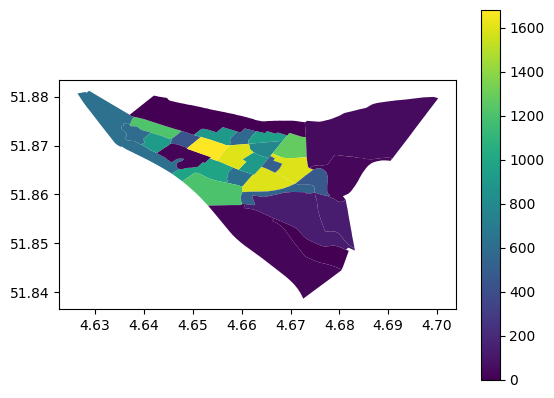

In [20]:
print(buurten_Alblasserdam.shape)
print(buurten_Alblasserdam.groupby('buurtnaam')['aantal_inwoners'].sum().sort_values(ascending=False))
buurten_Alblasserdam.plot(column='aantal_inwoners', legend=True, cmap='viridis')

### interactieve kaart - voor later

In [ ]:
import leafmap
# url = "https://fsn1.your-objectstorage.com/hwh-ortho/2022/Ortho/4/70/beelden_tif_tegels/2022_105000_431000_RGB_hrl.tif"
m = leafmap.Map(center=(40, -100), zoom=4)

tif_path = proces_data_dir / "nDSM_full.tif"

m.add_raster(
    str(tif_path),
    layer_name="alblasserdam_bomen",
    colormap="terrain",
    opacity=0.95,
)

m

Map(center=[51.867534000000006, 4.661148000000001], controls=(ZoomControl(options=['position', 'zoom_in_text',…